In [12]:
# =============================================
# Kaggle Setup - APTOS 2019 Blindness Detection
# =============================================
# Dataset: Add "aptos2019-blindness-detection" as a Kaggle dataset
# Go to: Add Data -> Competition Data -> aptos2019-blindness-detection
# The data will be at: /kaggle/input/aptos2019-blindness-detection/

import os

DATA_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'
SAVE_DIR = '/kaggle/working'

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_DIR}")
print(f"Data files: {os.listdir(DATA_DIR)}")

Data directory: /kaggle/input/competitions/aptos2019-blindness-detection
Output directory: /kaggle/working
Data files: ['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']


In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/aptos2019-blindness-detection
/kaggle/input/competitions/aptos2019-blindness-detection/train_images
/kaggle/input/competitions/aptos2019-blindness-detection/test_images
/kaggle/input/datasets
/kaggle/input/datasets/mariaherrerot


In [14]:
!pip install -q timm

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import timm
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


In [15]:
df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(f"Total samples: {len(df)}")
print(f"Class distribution:\n{df['diagnosis'].value_counts().sort_index()}")

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["diagnosis"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["diagnosis"], random_state=42
)

print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Total samples: 3662
Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Train: 2929, Val: 366, Test: 367


In [16]:
def apply_clahe(pil_img):
    img = np.array(pil_img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(img)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl,a,b))
    img = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return Image.fromarray(img)

In [17]:
# ImageNet normalization - CRITICAL for pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 456

train_transform = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms configured with ImageNet normalization + reduced augmentation")

Transforms configured with ImageNet normalization + reduced augmentation


In [18]:
class APTOSDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["id_code"]
        label = self.df.iloc[idx]["diagnosis"]

        path = os.path.join(self.data_dir, "train_images", f"{img_name}.png")
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


def mixup_data(x, y, alpha=0.4):
    """Mixup augmentation: blends pairs of images and their labels."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup loss: weighted combination of losses for both label sets."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [19]:
BATCH_SIZE = 8
NUM_WORKERS = 2

train_loader = DataLoader(
    APTOSDataset(train_df, DATA_DIR, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    APTOSDataset(val_df, DATA_DIR, val_transform),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    APTOSDataset(test_df, DATA_DIR, val_transform),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 366, Val batches: 46, Test batches: 46


In [20]:
# =============================================
# EfficientNet-B5 with pretrained ImageNet weights
# =============================================

model = timm.create_model("efficientnet_b5", pretrained=True, num_classes=5,
                          drop_rate=0.4, drop_path_rate=0.2).to(device)

# Replace classifier with a more regularized head
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.3),
    nn.Linear(256, 5)
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

Total params: 28,867,125
Trainable params: 28,867,125


In [21]:
class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df["diagnosis"]),
    y=train_df["diagnosis"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


In [22]:
def freeze_backbone(model):
    """Freeze all layers except the classifier head."""
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True

def unfreeze_all(model):
    """Unfreeze all layers for fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True

print("Helper functions defined: freeze_backbone, unfreeze_all")

Helper functions defined: freeze_backbone, unfreeze_all


In [23]:
def train_model(model, train_loader, val_loader, epochs=30, use_mixup=True, mixup_alpha=0.4):

    # Label smoothing cross entropy with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    # ==============================
    # STAGE 1: Warmup (classifier only)
    # ==============================
    freeze_backbone(model)
    warmup_params = [p for p in model.parameters() if p.requires_grad]
    print(f"Stage 1 - Trainable params (classifier only): {sum(p.numel() for p in warmup_params):,}")

    warmup_optimizer = torch.optim.Adam(warmup_params, lr=1e-3, weight_decay=1e-4)

    print("\n" + "="*60)
    print("STAGE 1: Warmup - Training classifier head (3 epochs)")
    print("="*60)

    for epoch in range(3):
        model.train()
        loop = tqdm(train_loader, desc=f"Warmup Epoch {epoch+1}/3")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            warmup_optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(warmup_params, max_norm=1.0)
            warmup_optimizer.step()
            loop.set_postfix(loss=loss.item())

    # ==============================
    # STAGE 2: Full Fine-tuning
    # ==============================
    unfreeze_all(model)

    all_params = list(model.parameters())
    print(f"\nStage 2 - All params unfrozen: {sum(p.numel() for p in all_params):,}")

    # Differential learning rates: backbone lower, head higher
    backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
    head_params = [p for n, p in model.named_parameters() if 'classifier' in n]

    optimizer = torch.optim.Adam([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': head_params, 'lr': 1e-4}
    ], weight_decay=1e-4)

    # Cosine annealing with warm restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-7
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_qwk = 0
    patience = 5
    patience_counter = 0

    save_path = os.path.join(SAVE_DIR, 'eff_best.pth')

    print("\n" + "="*60)
    print(f"STAGE 2: Full Fine-tuning ({epochs} epochs, patience={patience})")
    print("="*60 + "\n")

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()
        running_loss, correct, total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Apply Mixup with 50% probability during training
            if use_mixup and random.random() < 0.5:
                mixed_images, y_a, y_b, lam = mixup_data(images, labels, mixup_alpha)
                outputs = model(mixed_images)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                # For accuracy tracking, use original labels
                _, preds_batch = torch.max(outputs, 1)
                correct += (lam * (preds_batch == y_a).sum().item() +
                           (1 - lam) * (preds_batch == y_b).sum().item())
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds_batch = torch.max(outputs, 1)
                correct += (preds_batch == labels).sum().item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item(), acc=correct/total)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_loss_sum, correct, total = 0, 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item()
                _, preds_batch = torch.max(outputs, 1)
                correct += (preds_batch == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(preds_batch.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_loss_sum / len(val_loader)
        val_acc = correct / total
        val_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Print epoch results
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs} | LR: {current_lr:.2e}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val QWK: {val_qwk:.4f}")
        print(f"  Gap (Train-Val Acc): {(train_acc - val_acc):.4f}")
        print("-"*60)

        # Save best model based on val QWK
        if val_qwk > best_val_qwk:
            best_val_qwk = val_qwk
            patience_counter = 0
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_qwk': val_qwk,
                'train_acc': train_acc,
            }, save_path)
            print(f"  >>> Best model saved! Val QWK: {val_qwk:.4f}, Val Acc: {val_acc:.4f}")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")

        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

    print(f"\nTraining complete. Best Val QWK: {best_val_qwk:.4f}")
    print(f"Best model saved to: {save_path}")

    return train_losses, val_losses, train_accs, val_accs

In [24]:
trainable = [name for name, p in model.named_parameters() if p.requires_grad]
print(f"Total trainable layers: {len(trainable)}")
print("Last 10 trainable:", trainable[-10:])

Total trainable layers: 510
Last 10 trainable: ['blocks.6.2.bn3.bias', 'conv_head.weight', 'bn2.weight', 'bn2.bias', 'classifier.1.weight', 'classifier.1.bias', 'classifier.3.weight', 'classifier.3.bias', 'classifier.5.weight', 'classifier.5.bias']


In [25]:
history = train_model(model, train_loader, val_loader, epochs=20, use_mixup=True, mixup_alpha=0.4)

Stage 1 - Trainable params (classifier only): 526,341

STAGE 1: Warmup - Training classifier head (3 epochs)


Warmup Epoch 3/3: 100%|██████████| 366/366 [05:46<00:00,  1.06it/s, loss=1.43] 



Stage 2 - All params unfrozen: 28,867,125

STAGE 2: Full Fine-tuning (20 epochs, patience=5)



Epoch 1/20: 100%|██████████| 366/366 [06:19<00:00,  1.04s/it, acc=0.635, loss=1.45] 



Epoch 1/20 | LR: 9.05e-06
  Train Loss: 1.4828 | Train Acc: 0.6351
  Val   Loss: 1.4196 | Val   Acc: 0.7404 | Val QWK: 0.8028
  Gap (Train-Val Acc): -0.1053
------------------------------------------------------------
  >>> Best model saved! Val QWK: 0.8028, Val Acc: 0.7404


...


Epoch 14/20 | LR: 3.42e-07
  Train Loss: 1.2214 | Train Acc: 0.7927
  Val   Loss: 1.2832 | Val   Acc: 0.8169 | Val QWK: 0.8817
  Gap (Train-Val Acc): -0.0243
------------------------------------------------------------
  No improvement. Patience: 3/5


Epoch 15/20: 100%|██████████| 366/366 [06:25<00:00,  1.05s/it, acc=0.8, loss=1.5]    



Epoch 15/20 | LR: 1.00e-05
  Train Loss: 1.2247 | Train Acc: 0.8002
  Val   Loss: 1.2516 | Val   Acc: 0.8224 | Val QWK: 0.8866
  Gap (Train-Val Acc): -0.0222
------------------------------------------------------------
  No improvement. Patience: 4/5


Epoch 16/20: 100%|██████████| 366/366 [06:24<00:00,  1.05s/it, acc=0.788, loss=0.856]



Epoch 16/20 | LR: 9.94e-06
  Train Loss: 1.2278 | Train Acc: 0.7880
  Val   Loss: 1.2565 | Val   Acc: 0.8115 | Val QWK: 0.8862
  Gap (Train-Val Acc): -0.0235
------------------------------------------------------------
  No improvement. Patience: 5/5

Early stopping triggered at epoch 16!

Training complete. Best Val QWK: 0.8879
Best model saved to: /kaggle/working/eff_best.pth


In [ ]:
def plot_history(history):
    train_losses, val_losses, train_accs, val_accs = history

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    axes[0].plot(train_losses, label="Train Loss", linewidth=2)
    axes[0].plot(val_losses, label="Validation Loss", linewidth=2)
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(train_accs, label="Train Accuracy", linewidth=2)
    axes[1].plot(val_accs, label="Validation Accuracy", linewidth=2)
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Gap plot (overfitting indicator)
    gaps = [t - v for t, v in zip(train_accs, val_accs)]
    axes[2].plot(gaps, label="Train-Val Acc Gap", linewidth=2, color='red')
    axes[2].axhline(y=0.05, color='green', linestyle='--', label='Acceptable gap (5%)')
    axes[2].set_xlabel("Epochs")
    axes[2].set_ylabel("Accuracy Gap")
    axes[2].set_title("Overfitting Gap (Lower is Better)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)

In [28]:
# Load best model for evaluation
checkpoint = torch.load(os.path.join(SAVE_DIR, 'eff_best.pth'), map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Val Acc: {checkpoint['val_acc']:.4f}, Best Val QWK: {checkpoint['val_qwk']:.4f}")

model.eval()

preds, labels_all = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)

        preds.extend(outputs.argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(classification_report(labels_all, preds,
      target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']))
print(f"Quadratic Weighted Kappa: {cohen_kappa_score(labels_all, preds, weights='quadratic'):.4f}")
print(f"Test Accuracy: {np.mean(np.array(preds) == np.array(labels_all)):.4f}")

Loaded best model from epoch 11
Best Val Acc: 0.8169, Best Val QWK: 0.8879


Testing: 100%|██████████| 46/46 [00:51<00:00,  1.11s/it]


TEST SET RESULTS
               precision    recall  f1-score   support

        No DR       0.97      0.97      0.97       181
         Mild       0.62      0.68      0.65        37
     Moderate       0.86      0.79      0.82       100
       Severe       0.44      0.63      0.52        19
Proliferative       0.70      0.63      0.67        30

     accuracy                           0.85       367
    macro avg       0.72      0.74      0.73       367
 weighted avg       0.86      0.85      0.85       367

Quadratic Weighted Kappa: 0.9201
Test Accuracy: 0.8474


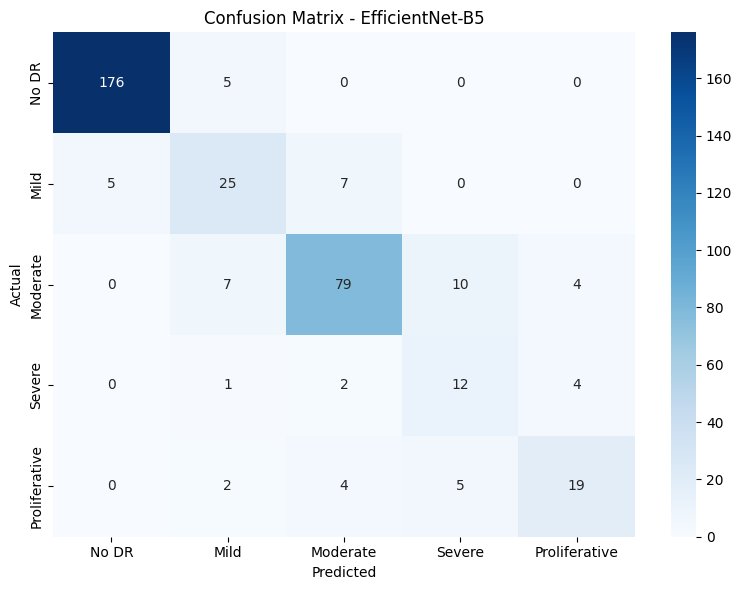

In [29]:
cm = confusion_matrix(labels_all, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
            yticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNet-B5")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [2]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents']
